# Social Media Impact on Health â€” Full Data Science Project

**Dataset:** [Impact of Social Media on Health (Kaggle)](https://www.kaggle.com/datasets/sumeakash/impact-of-social-media-on-health)  
**Goal:** Predict `Overall_Impact` (Negative / Neutral / Positive) from student social media habits.

---

## Project Roadmap

| Step | Description |
|------|-------------|
| 1 | Data Loading & Initial Inspection |
| 2 | Exploratory Data Analysis (EDA) |
| 3 | Preprocessing & Feature Engineering |
| 4 | Baseline Classification Models |
| 5 | Model Improvement (Hyperparameter Tuning + Ensemble) |
| 6 | SHAP Explainability |

---

## Setup â€” Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings, os

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score, GridSearchCV)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               VotingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')

# Color palette for the 3 target classes
PALETTE = {'Negative': '#E74C3C', 'Neutral': '#F39C12', 'Positive': '#2ECC71'}
DATA_PATH = 'Social_media_impact_on_life.csv'

print('All libraries loaded successfully!')

All libraries loaded successfully!


---
## Step 1 â€” Data Loading & Initial Inspection

We start by loading the CSV and taking a first look at the structure, types, and basic statistics.
Key questions at this stage:
- How many rows and columns do we have?
- Are there any missing values?
- What does each column represent?

In [3]:
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()  # keep a clean original copy

print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Dataset shape: 1705 rows x 11 columns


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative


In [5]:
df.groupby('Most_Used_Platform')['Overall_Impact'].value_counts()

Most_Used_Platform  Overall_Impact
Facebook            Negative          110
                    Positive          109
                    Neutral            37
Instagram           Negative          241
                    Positive          121
                    Neutral            27
KakaoTalk           Negative           12
LINE                Neutral            12
LinkedIn            Positive           65
                    Negative           58
                    Neutral            53
Snapchat            Negative           81
                    Neutral            37
                    Positive           31
TikTok              Negative          217
                    Positive           52
                    Neutral            26
Twitter             Negative           77
                    Positive           54
                    Neutral            39
VKontakte           Positive           12
WeChat              Negative            8
                    Positive            7

In [ ]:
# Column data types
print('Column types:')
print(df.dtypes)

Column types:
Student_ID                        int64
Age                               int64
Gender                           object
Academic_Level                   object
Country                          object
Avg_Daily_Usage_Hours           float64
Most_Used_Platform               object
Affects_Academic_Performance     object
Sleep_Hours_Per_Night           float64
Mental_Health_Score             float64
Overall_Impact                   object
dtype: object


In [ ]:
# Check for missing values â€” important before any analysis
print('Missing values per column:')
print(df.isnull().sum())
print('\nGreat â€” no missing values!')

Missing values per column:
Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Overall_Impact                  0
dtype: int64

Great â€” no missing values!


In [ ]:
# Statistical summary for numeric columns
df.describe().round(2)

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,1705.00,1705.00,1705.00,1705.00,1705.00
mean,439.51,20.85,5.10,6.60,6.22
std,267.06,1.76,1.68,1.21,1.28
min,1.00,18.00,1.50,3.80,4.00
25%,214.00,19.00,3.80,5.60,5.00
50%,427.00,21.00,5.10,6.60,6.00
75%,640.00,22.00,6.30,7.50,7.00
max,1000.00,24.00,8.50,9.60,9.00


**Column glossary:**

| Column | Type | Description |
|--------|------|-------------|
| `Student_ID` | int | Unique identifier (not a feature) |
| `Age` | int | Student age (18â€“24) |
| `Gender` | str | Male / Female |
| `Academic_Level` | str | High School / Undergraduate / Graduate |
| `Country` | str | Country of origin (111 unique) |
| `Avg_Daily_Usage_Hours` | float | Hours spent on social media per day |
| `Most_Used_Platform` | str | Primary social media platform |
| `Affects_Academic_Performance` | str | Self-reported Yes/No |
| `Sleep_Hours_Per_Night` | float | Average hours of sleep |
| `Mental_Health_Score` | float | Self-reported score (1â€“10) |
| `Overall_Impact` | str | **Target**: Negative / Neutral / Positive |

---
## Step 2 â€” Exploratory Data Analysis (EDA)

EDA is about understanding the data before modeling. We look at:
1. How balanced our target class is
2. How numeric features are distributed and differ between classes
3. How categorical features relate to the target
4. Correlations between numeric features
5. Platform-specific patterns

### 2.1 â€” Target Class Distribution

Understanding class balance is critical â€” an imbalanced dataset can trick a model into always predicting the majority class.

In [ ]:
counts = df['Overall_Impact'].value_counts()
print('Class counts:')
print(counts)
print('\nClass proportions:')
print((counts / len(df)).round(3))

Class counts:
Overall_Impact
Negative    939
Positive    499
Neutral     267
Name: count, dtype: int64

Class proportions:
Overall_Impact
Negative    0.551
Positive    0.293
Neutral     0.157
Name: count, dtype: float64


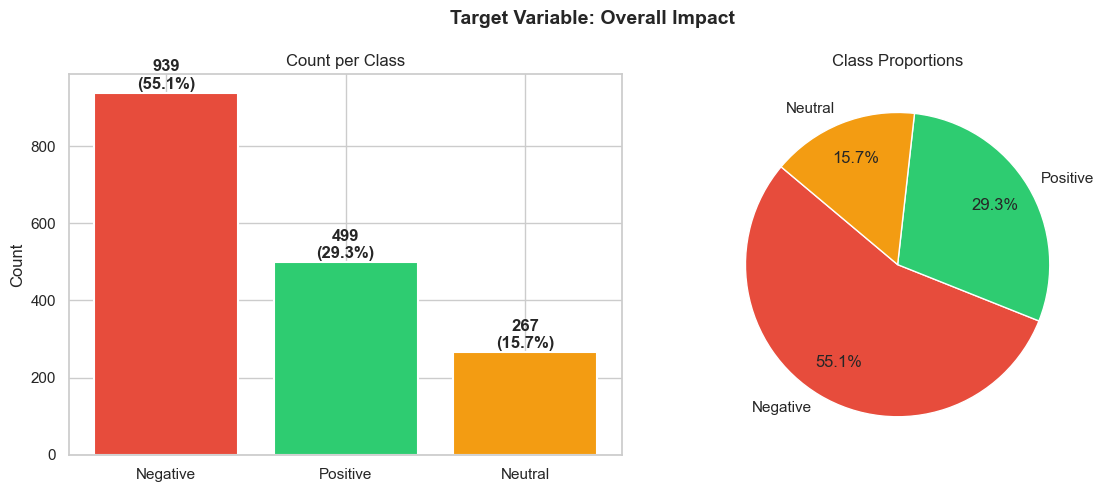

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Target Variable: Overall Impact', fontsize=14, fontweight='bold')

# Bar chart
axes[0].bar(counts.index, counts.values,
            color=[PALETTE[c] for c in counts.index], edgecolor='white', linewidth=1.5)
for i, (k, v) in enumerate(counts.items()):
    axes[0].text(i, v + 10, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Count per Class')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(counts.values, labels=counts.index,
            colors=[PALETTE[c] for c in counts.index],
            autopct='%1.1f%%', startangle=140, pctdistance=0.75)
axes[1].set_title('Class Proportions')

plt.tight_layout()
plt.show()

> **Observation:** The dataset is **moderately imbalanced** â€” Negative is the majority class (55%), while Neutral is the rarest (16%). This is worth keeping in mind when evaluating models; accuracy alone would be misleading, so we'll use **weighted F1-score**.

### 2.2 â€” Numeric Feature Distributions

We look at how each numeric feature is distributed **overall** (histogram) and **split by target class** (boxplot). If a feature separates classes well, it's likely to be useful for prediction.

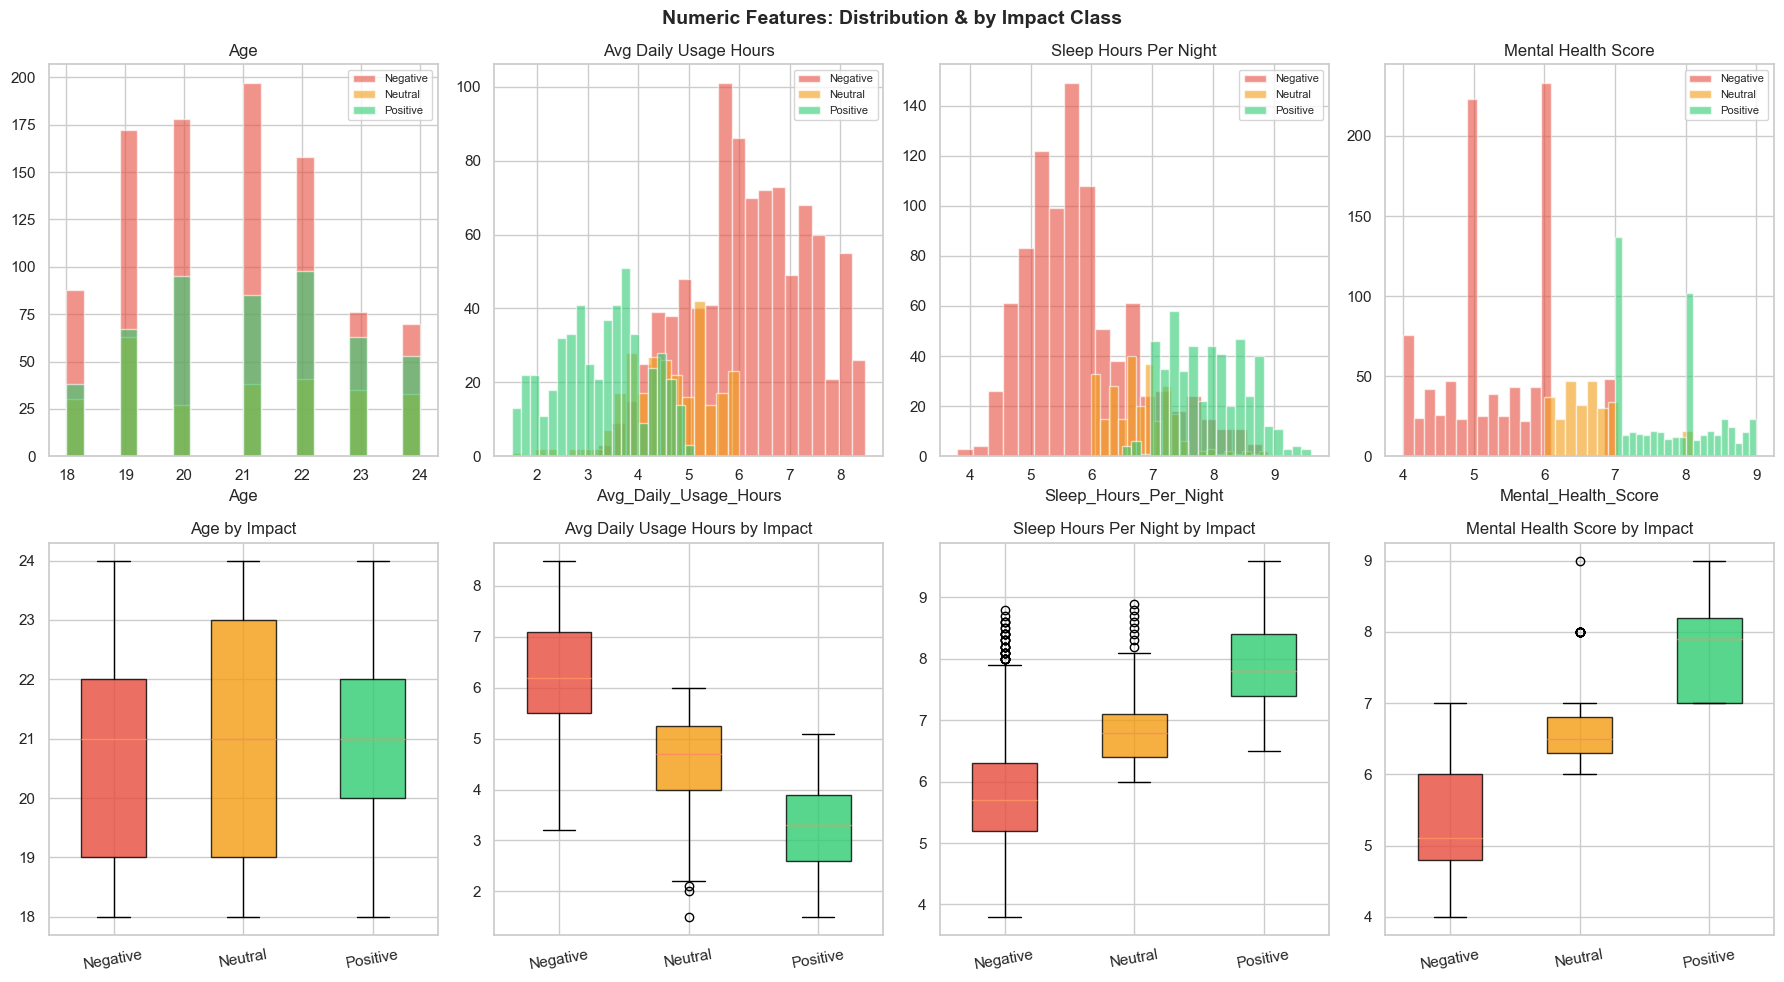

In [ ]:
num_cols = ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score']
order = ['Negative', 'Neutral', 'Positive']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Numeric Features: Distribution & by Impact Class', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols):
    # Row 1: overlaid histograms per class
    for impact, grp in df.groupby('Overall_Impact'):
        axes[0, i].hist(grp[col], alpha=0.6, label=impact, bins=20,
                        color=PALETTE[impact], edgecolor='white')
    axes[0, i].set_title(col.replace('_', ' '))
    axes[0, i].set_xlabel(col)
    axes[0, i].legend(fontsize=8)

    # Row 2: boxplots per class
    data_plot = [df[df['Overall_Impact'] == o][col].values for o in order]
    bp = axes[1, i].boxplot(data_plot, patch_artist=True, labels=order, widths=0.5)
    for patch, label in zip(bp['boxes'], order):
        patch.set_facecolor(PALETTE[label])
        patch.set_alpha(0.8)
    axes[1, i].set_title(f'{col.replace("_", " ")} by Impact')
    axes[1, i].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

> **Key Observations:**
> - **`Avg_Daily_Usage_Hours`** is the single strongest separator: negative-impact students average **~6.2h/day** vs ~**3.3h** for positive-impact ones.
> - **`Mental_Health_Score`** shows a clear gradient: Negative (~5.3) â†’ Neutral (~6.5) â†’ Positive (~7.8).
> - **`Sleep_Hours_Per_Night`** follows the same trend â€” less sleep correlates with negative impact.
> - **`Age`** has almost no separation between classes â€” it's likely a weak predictor.

### 2.3 â€” Categorical Features vs Target

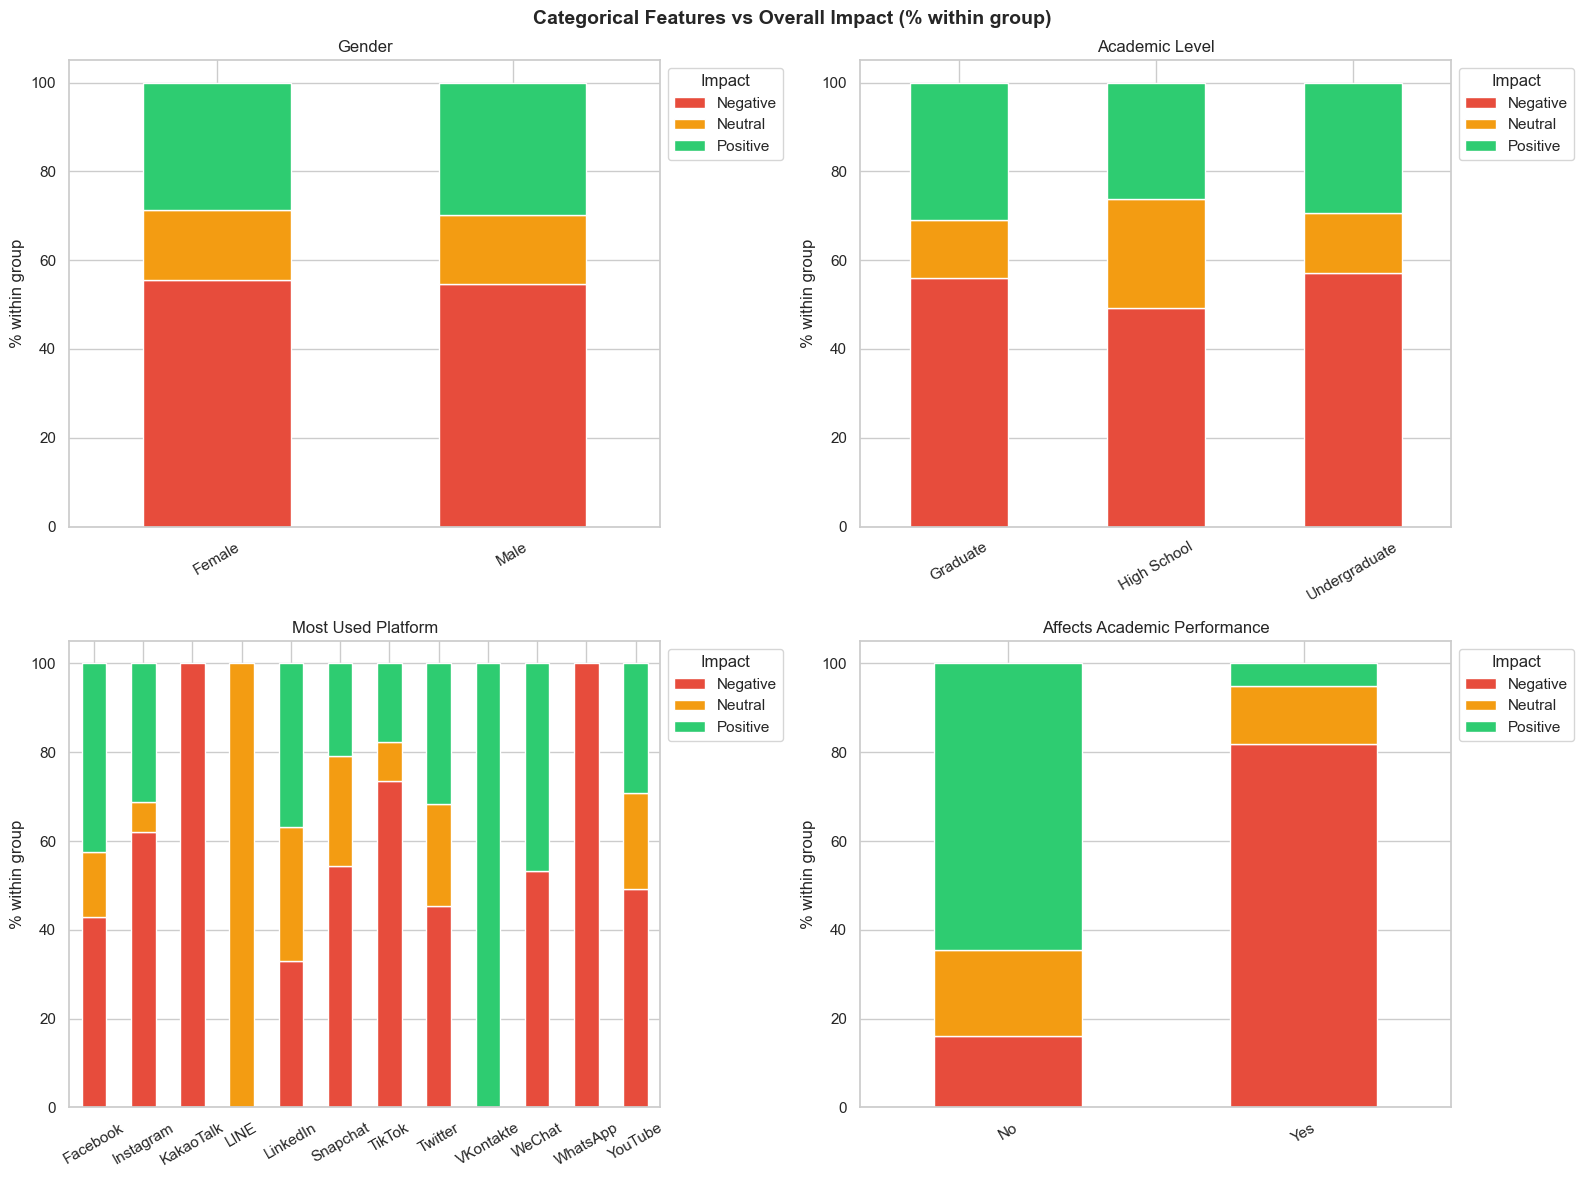

In [ ]:
cat_cols = ['Gender', 'Academic_Level', 'Most_Used_Platform', 'Affects_Academic_Performance']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Categorical Features vs Overall Impact (% within group)', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), cat_cols):
    # Normalize=index gives us the % breakdown within each category group
    ct = pd.crosstab(df[col], df['Overall_Impact'], normalize='index') * 100
    ct = ct[['Negative', 'Neutral', 'Positive']]
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=[PALETTE[c] for c in ct.columns], edgecolor='white')
    ax.set_title(col.replace('_', ' '))
    ax.set_xlabel('')
    ax.set_ylabel('% within group')
    ax.legend(title='Impact', bbox_to_anchor=(1, 1))
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

> **Observations:**
> - **`Affects_Academic_Performance = Yes`** strongly associates with negative impact.
> - **Platform** matters: TikTok and Snapchat users tend to report more negative impact; LinkedIn users tend to report positive.
> - **Gender** and **Academic Level** show smaller but visible differences.

### 2.4 â€” Correlation Heatmap

Correlations between numeric features tell us if any features are redundant (highly correlated with each other).

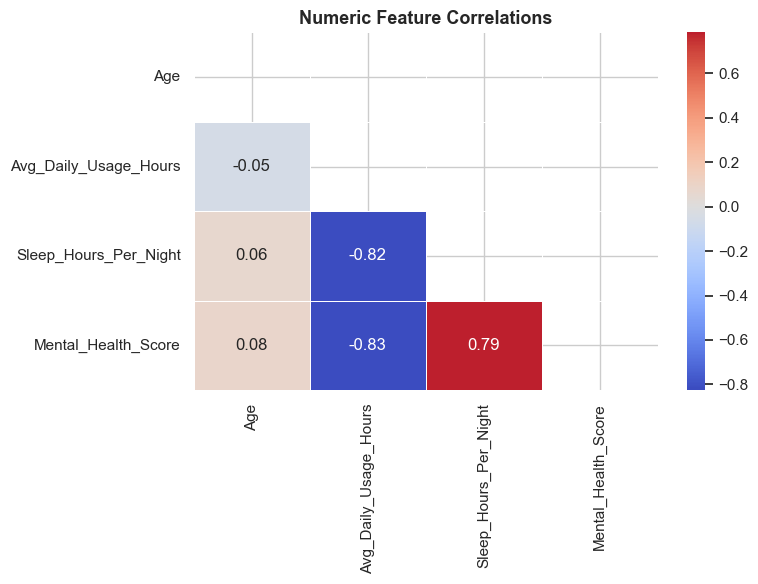

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide the upper triangle (it's a mirror)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Numeric Feature Correlations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Observation:** `Mental_Health_Score` and `Sleep_Hours_Per_Night` have a **moderate positive correlation** (~0.4). The others are mostly independent â€” no severe multicollinearity to worry about.

### 2.5 â€” Platform Deep-Dive

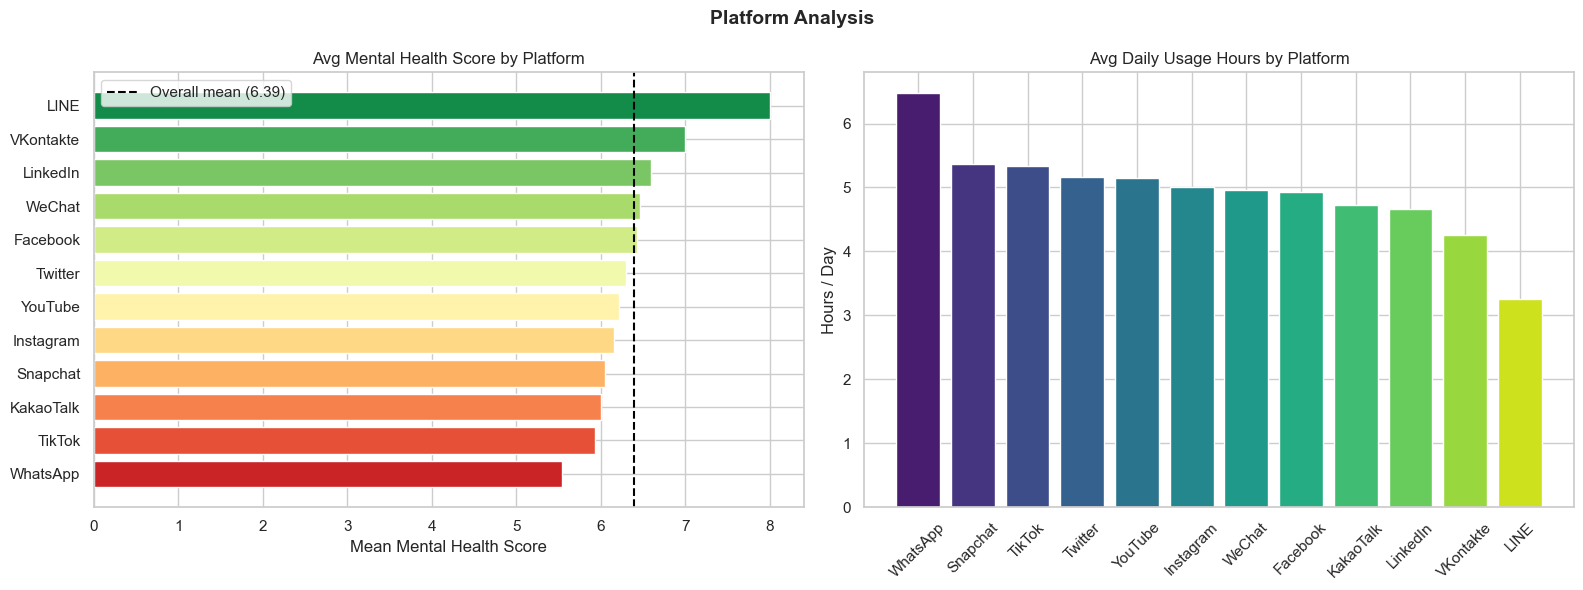

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Platform Analysis', fontsize=14, fontweight='bold')

# Mental health score per platform (sorted lowest to highest)
ph = df.groupby('Most_Used_Platform')['Mental_Health_Score'].mean().sort_values()
axes[0].barh(ph.index, ph.values, color=sns.color_palette('RdYlGn', len(ph)))
axes[0].axvline(ph.mean(), color='black', linestyle='--', label=f'Overall mean ({ph.mean():.2f})')
axes[0].set_title('Avg Mental Health Score by Platform')
axes[0].set_xlabel('Mean Mental Health Score')
axes[0].legend()

# Average usage hours per platform
pu = df.groupby('Most_Used_Platform')['Avg_Daily_Usage_Hours'].mean().sort_values(ascending=False)
axes[1].bar(pu.index, pu.values, color=sns.color_palette('viridis', len(pu)))
axes[1].set_title('Avg Daily Usage Hours by Platform')
axes[1].set_ylabel('Hours / Day')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## Step 3 â€” Preprocessing & Feature Engineering

Machine learning models work with numbers, not text. We need to:
1. **Encode categorical variables** into numbers
2. **Create new features** that might capture patterns not obvious in the raw data
3. **Scale** numeric features for models sensitive to magnitude (e.g., SVM, Logistic Regression)

In [ ]:
df_model = df.drop(columns=['Student_ID']).copy()  # Student_ID is just an identifier, not informative

# --- Encode the target ---
# We map the 3 classes to integers: Negative=0, Neutral=1, Positive=2
target_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
df_model['target'] = df_model['Overall_Impact'].map(target_map)

# --- Binary encode simple yes/no and 2-category columns ---
df_model['Gender_enc'] = (df_model['Gender'] == 'Female').astype(int)          # Female=1, Male=0
df_model['AcadPerf_enc'] = (df_model['Affects_Academic_Performance'] == 'Yes').astype(int)  # Yes=1

# --- Ordinal encode Academic Level (there's a natural order: HS < UG < Grad) ---
df_model['AcadLevel_enc'] = df_model['Academic_Level'].map(
    {'High School': 0, 'Undergraduate': 1, 'Graduate': 2})

# --- One-hot encode Platform (keep top 7, group the rest as 'Other') ---
# One-hot creates a separate 0/1 column for each platform
top_platforms = df_model['Most_Used_Platform'].value_counts().nlargest(7).index
df_model['Platform_grp'] = df_model['Most_Used_Platform'].where(
    df_model['Most_Used_Platform'].isin(top_platforms), 'Other')
platform_dummies = pd.get_dummies(df_model['Platform_grp'], prefix='plt')

# --- One-hot encode Country (keep top 5, group the rest as 'Other') ---
top_countries = df_model['Country'].value_counts().nlargest(5).index
df_model['Country_grp'] = df_model['Country'].where(
    df_model['Country'].isin(top_countries), 'Other')
country_dummies = pd.get_dummies(df_model['Country_grp'], prefix='ctry')

print('Platforms kept:', list(top_platforms))
print('Countries kept:', list(top_countries))

Platforms kept: ['Instagram', 'TikTok', 'Facebook', 'LinkedIn', 'Twitter', 'YouTube', 'Snapchat']
Countries kept: ['Other', 'India', 'USA', 'Canada', 'Australia']


In [ ]:
# --- Feature Engineering ---
# Create new features that might be more informative than the raw ones

# Ratio of usage to sleep â€” high usage + low sleep could signal problematic use
df_model['UsageSleep_ratio'] = df_model['Avg_Daily_Usage_Hours'] / (df_model['Sleep_Hours_Per_Night'] + 1e-5)

# Interaction of mental health and sleep â€” both together may better capture wellbeing
df_model['HealthSleep_product'] = df_model['Mental_Health_Score'] * df_model['Sleep_Hours_Per_Night']

# Binary flag: is the student a heavy user (above median)?
median_usage = df_model['Avg_Daily_Usage_Hours'].median()
df_model['HighUsage'] = (df_model['Avg_Daily_Usage_Hours'] > median_usage).astype(int)

print(f'Median daily usage: {median_usage:.2f}h (used as HighUsage threshold)')

# --- Assemble final feature matrix X ---
base_features = [
    'Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score',
    'Gender_enc', 'AcadPerf_enc', 'AcadLevel_enc',
    'UsageSleep_ratio', 'HealthSleep_product', 'HighUsage'
]

X = pd.concat([df_model[base_features], platform_dummies, country_dummies], axis=1)
y = df_model['target']

print(f'\nFinal feature matrix: {X.shape[0]} rows x {X.shape[1]} features')
print('Features:', list(X.columns))

Median daily usage: 5.10h (used as HighUsage threshold)

Final feature matrix: 1705 rows x 23 features
Features: ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Gender_enc', 'AcadPerf_enc', 'AcadLevel_enc', 'UsageSleep_ratio', 'HealthSleep_product', 'HighUsage', 'plt_Facebook', 'plt_Instagram', 'plt_LinkedIn', 'plt_Other', 'plt_Snapchat', 'plt_TikTok', 'plt_Twitter', 'plt_YouTube', 'ctry_Australia', 'ctry_Canada', 'ctry_India', 'ctry_Other', 'ctry_USA']


In [ ]:
# --- Train / Test Split ---
# We use stratify=y to make sure each split has the same class proportions as the full dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set:   {X_train.shape[0]} samples')
print(f'Test set:       {X_test.shape[0]} samples')
print(f'\nClass distribution in train: {dict(pd.Series(y_train).value_counts().sort_index())}')
print(f'Class distribution in test:  {dict(pd.Series(y_test).value_counts().sort_index())}')

Training set:   1364 samples
Test set:       341 samples

Class distribution in train: {0: np.int64(751), 1: np.int64(214), 2: np.int64(399)}
Class distribution in test:  {0: np.int64(188), 1: np.int64(53), 2: np.int64(100)}


In [ ]:
# --- Scale Features ---
# StandardScaler transforms features to have mean=0, std=1
# Important for distance-based models (KNN, SVM) and linear models (Logistic Regression)
# Tree-based models (Random Forest, Gradient Boosting) don't need scaling

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit on train, then transform
X_test_sc = scaler.transform(X_test)        # only transform test (never fit on test!)

print('Scaling done.')
print(f'Train mean (first 3 features): {X_train_sc[:, :3].mean(axis=0).round(4)}')
print(f'Train std  (first 3 features): {X_train_sc[:, :3].std(axis=0).round(4)}')

Scaling done.
Train mean (first 3 features): [ 0. -0.  0.]
Train std  (first 3 features): [1. 1. 1.]


---
## Step 4 â€” Baseline Classification Models

Before optimizing, we train several different model types with **default settings** to get a sense of what works best on this data. This is called a **baseline**.

We evaluate each model using:
- **5-fold Stratified Cross-Validation** on the training set (more reliable than a single split)
- **Test set performance** on the held-out 20%
- **Metric: Weighted F1-score** (handles class imbalance better than accuracy)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
label_names = ['Negative', 'Neutral', 'Positive']

# Models to compare
baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Naive Bayes':         GaussianNB(),
    'SVM':                 SVC(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

baseline_results = {}

for name, model in baseline_models.items():
    # Some models need scaled data, tree-based ones don't
    use_scaled = name in ('Logistic Regression', 'K-Nearest Neighbors', 'SVM')
    X_tr = X_train_sc if use_scaled else X_train.values
    X_te = X_test_sc  if use_scaled else X_test.values

    # Cross-validation score
    cv_scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring='f1_weighted', n_jobs=-1)

    # Fit and predict on test set
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    acc   = accuracy_score(y_test, y_pred)
    f1_w  = f1_score(y_test, y_pred, average='weighted')
    f1_m  = f1_score(y_test, y_pred, average='macro')

    baseline_results[name] = {
        'CV_F1_mean': cv_scores.mean(), 'CV_F1_std': cv_scores.std(),
        'Test_Acc': acc, 'Test_F1_weighted': f1_w, 'Test_F1_macro': f1_m,
        'model': model, 'X_te': X_te
    }
    print(f'{name:<25}  CV F1={cv_scores.mean():.3f}+/-{cv_scores.std():.3f}  '
          f'Acc={acc:.3f}  F1(w)={f1_w:.3f}')

Logistic Regression        CV F1=0.922+/-0.018  Acc=0.906  F1(w)=0.904


K-Nearest Neighbors        CV F1=0.863+/-0.009  Acc=0.921  F1(w)=0.914
Decision Tree              CV F1=0.973+/-0.008  Acc=0.991  F1(w)=0.991
Naive Bayes                CV F1=0.894+/-0.020  Acc=0.880  F1(w)=0.881


SVM                        CV F1=0.957+/-0.014  Acc=0.974  F1(w)=0.973


Random Forest              CV F1=0.980+/-0.007  Acc=0.991  F1(w)=0.991


Gradient Boosting          CV F1=0.979+/-0.006  Acc=0.994  F1(w)=0.994


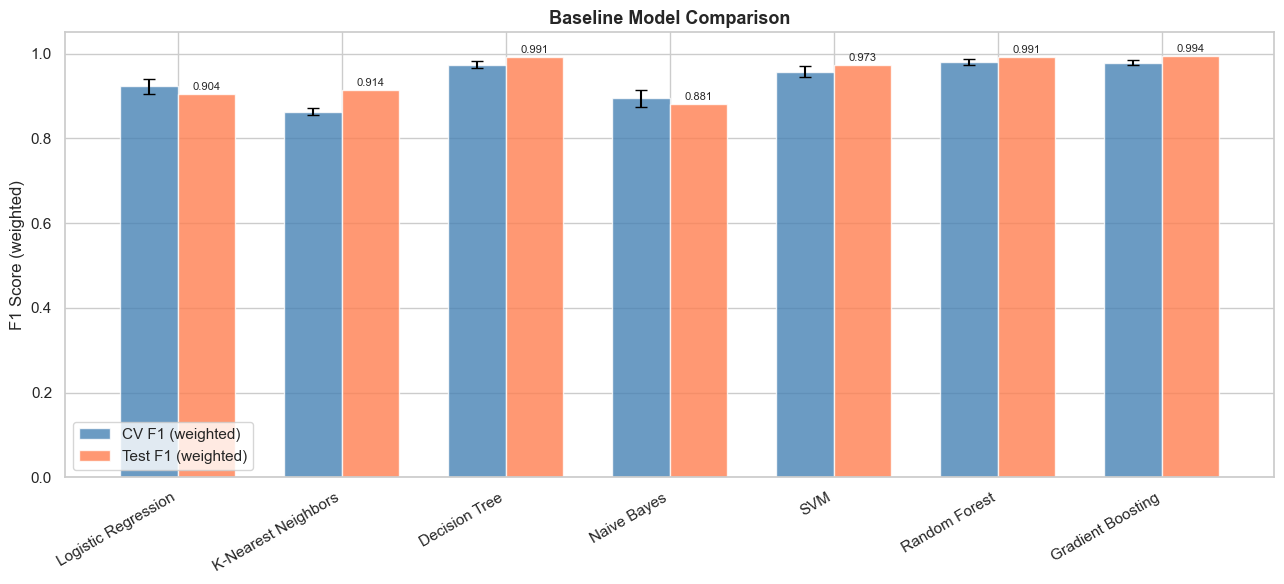

In [ ]:
# Visualize baseline comparison
names     = list(baseline_results.keys())
cv_means  = [baseline_results[n]['CV_F1_mean'] for n in names]
cv_stds   = [baseline_results[n]['CV_F1_std']  for n in names]
test_f1s  = [baseline_results[n]['Test_F1_weighted'] for n in names]

x, w = np.arange(len(names)), 0.35
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - w/2, cv_means, w, yerr=cv_stds, label='CV F1 (weighted)',
       color='steelblue', alpha=0.8, capsize=4)
bars2 = ax.bar(x + w/2, test_f1s, w, label='Test F1 (weighted)', color='coral', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha='right')
ax.set_ylabel('F1 Score (weighted)')
ax.set_title('Baseline Model Comparison', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

Best baseline: Gradient Boosting

              precision    recall  f1-score   support

    Negative       0.99      1.00      1.00       188
     Neutral       1.00      0.96      0.98        53
    Positive       0.99      1.00      1.00       100

    accuracy                           0.99       341
   macro avg       0.99      0.99      0.99       341
weighted avg       0.99      0.99      0.99       341



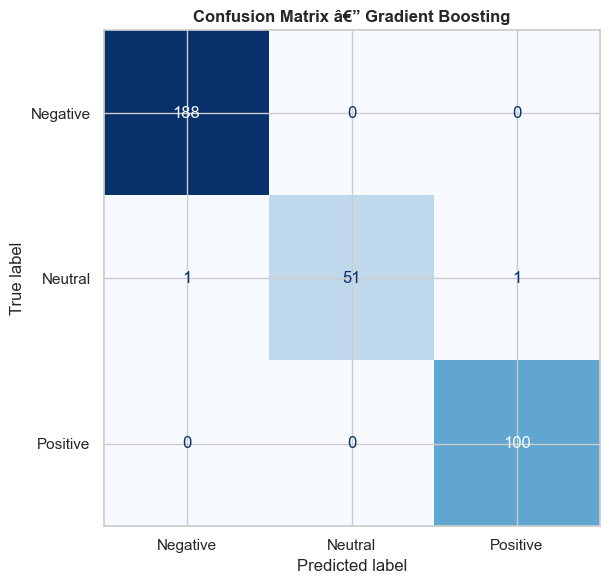

In [ ]:
# Detailed report for the best baseline
best_name = max(baseline_results, key=lambda n: baseline_results[n]['Test_F1_weighted'])
best = baseline_results[best_name]
y_pred_best = best['model'].predict(best['X_te'])

print(f'Best baseline: {best_name}\n')
print(classification_report(y_test, y_pred_best, target_names=label_names))

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=label_names).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix â€” {best_name}', fontweight='bold')
plt.tight_layout()
plt.show()

> **Reading the confusion matrix:** Rows are the **actual** class, columns are the **predicted** class. The diagonal (top-left to bottom-right) contains correct predictions. Off-diagonal cells are mistakes.

> **Observation:** Tree-based models (Gradient Boosting, Random Forest, Decision Tree) significantly outperform linear models. This suggests the decision boundaries in the data are **non-linear**.

---
## Step 5 â€” Model Improvement

Now we improve on the best baselines using:
1. **Grid Search Cross-Validation** â€” systematically try many combinations of hyperparameters to find the best settings
2. **Soft Voting Ensemble** â€” combine predictions from multiple models, where each model votes with confidence (probability), not just a binary yes/no

### 5.1 â€” Hyperparameter Tuning

In [ ]:
# --- Random Forest Grid Search ---
# Key hyperparameters:
#   n_estimators: how many trees to build
#   max_depth: how deep each tree can grow (None = unlimited)
#   min_samples_split: minimum samples needed to split a node
#   max_features: how many features to consider at each split
#   class_weight: 'balanced' compensates for class imbalance

print('Running Random Forest Grid Search...')
rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid={
        'n_estimators':     [100, 200, 300],
        'max_depth':        [None, 10, 20],
        'min_samples_split':[2, 5],
        'max_features':     ['sqrt', 'log2'],
        'class_weight':     ['balanced', None],
    },
    cv=cv, scoring='f1_weighted', n_jobs=-1)
rf_gs.fit(X_train.values, y_train)
print(f'  Best params: {rf_gs.best_params_}')
print(f'  Best CV F1:  {rf_gs.best_score_:.4f}')

Running Random Forest Grid Search...


  Best params: {'class_weight': None, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
  Best CV F1:  0.9838


In [ ]:
# --- Gradient Boosting Grid Search ---
# Key hyperparameters:
#   n_estimators: number of boosting stages
#   learning_rate: how much each tree corrects the previous (lower = slower but more accurate)
#   max_depth: depth of each tree (shallower = less overfitting)
#   subsample: fraction of training data used per stage (< 1.0 adds randomness, reduces overfitting)

print('Running Gradient Boosting Grid Search...')
gb_gs = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid={
        'n_estimators':  [100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth':     [3, 5],
        'subsample':     [0.8, 1.0],
    },
    cv=cv, scoring='f1_weighted', n_jobs=-1)
gb_gs.fit(X_train.values, y_train)
print(f'  Best params: {gb_gs.best_params_}')
print(f'  Best CV F1:  {gb_gs.best_score_:.4f}')

Running Gradient Boosting Grid Search...


  Best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
  Best CV F1:  0.9807


In [ ]:
# --- Logistic Regression Grid Search ---
# Key hyperparameters:
#   C: regularization strength (smaller C = more regularization = simpler model)
#   solver: optimization algorithm
#   class_weight: 'balanced' compensates for class imbalance

print('Running Logistic Regression Grid Search...')
lr_gs = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid={
        'C':            [0.01, 0.1, 1, 10],
        'solver':       ['lbfgs', 'saga'],
        'class_weight': [None, 'balanced'],
    },
    cv=cv, scoring='f1_weighted', n_jobs=-1)
lr_gs.fit(X_train_sc, y_train)
print(f'  Best params: {lr_gs.best_params_}')
print(f'  Best CV F1:  {lr_gs.best_score_:.4f}')

Running Logistic Regression Grid Search...


  Best params: {'C': 10, 'class_weight': None, 'solver': 'lbfgs'}
  Best CV F1:  0.9321


In [ ]:
# Evaluate tuned models on the test set
print('Tuned model test performance:\n')

tuned_results = {}
for name, (model, X_te) in [
    ('RF (tuned)', (rf_gs.best_estimator_, X_test.values)),
    ('GB (tuned)', (gb_gs.best_estimator_, X_test.values)),
    ('LR (tuned)', (lr_gs.best_estimator_, X_test_sc)),
]:
    y_pred = model.predict(X_te)
    acc  = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average='weighted')
    f1_m = f1_score(y_test, y_pred, average='macro')
    tuned_results[name] = {'Acc': acc, 'F1_weighted': f1_w, 'F1_macro': f1_m}
    print(f'{name:<20}  Acc={acc:.3f}  F1(w)={f1_w:.3f}  F1(macro)={f1_m:.3f}')

Tuned model test performance:

RF (tuned)            Acc=0.991  F1(w)=0.991  F1(macro)=0.989
GB (tuned)            Acc=0.991  F1(w)=0.991  F1(macro)=0.986
LR (tuned)            Acc=0.933  F1(w)=0.931  F1(macro)=0.904


### 5.2 â€” Soft Voting Ensemble

A **Voting Ensemble** combines multiple models. With `voting='soft'`, each model outputs a **probability** for each class, and the probabilities are averaged before making the final prediction. This tends to be more robust than any single model.

We wrap LR in a Pipeline so it gets its own scaler internally, and all three models work on the same unscaled data from outside.

In [ ]:
# Wrap the LR in a pipeline (it needs scaling, but the VotingClassifier uses unscaled X)
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', lr_gs.best_estimator_)
])
lr_pipe.fit(X_train.values, y_train)

voting_clf = VotingClassifier(
    estimators=[
        ('rf', rf_gs.best_estimator_),
        ('gb', gb_gs.best_estimator_),
        ('lr', lr_pipe),
    ],
    voting='soft',  # use probabilities, not just votes
    n_jobs=-1
)
voting_clf.fit(X_train.values, y_train)

y_pred_vote = voting_clf.predict(X_test.values)
acc_vote    = accuracy_score(y_test, y_pred_vote)
f1_vote_w   = f1_score(y_test, y_pred_vote, average='weighted')
f1_vote_m   = f1_score(y_test, y_pred_vote, average='macro')

print(f'Voting Ensemble  Acc={acc_vote:.3f}  F1(w)={f1_vote_w:.3f}  F1(macro)={f1_vote_m:.3f}\n')
print(classification_report(y_test, y_pred_vote, target_names=label_names))

Voting Ensemble  Acc=0.994  F1(w)=0.994  F1(macro)=0.991

              precision    recall  f1-score   support

    Negative       0.99      1.00      1.00       188
     Neutral       1.00      0.96      0.98        53
    Positive       0.99      1.00      1.00       100

    accuracy                           0.99       341
   macro avg       0.99      0.99      0.99       341
weighted avg       0.99      0.99      0.99       341



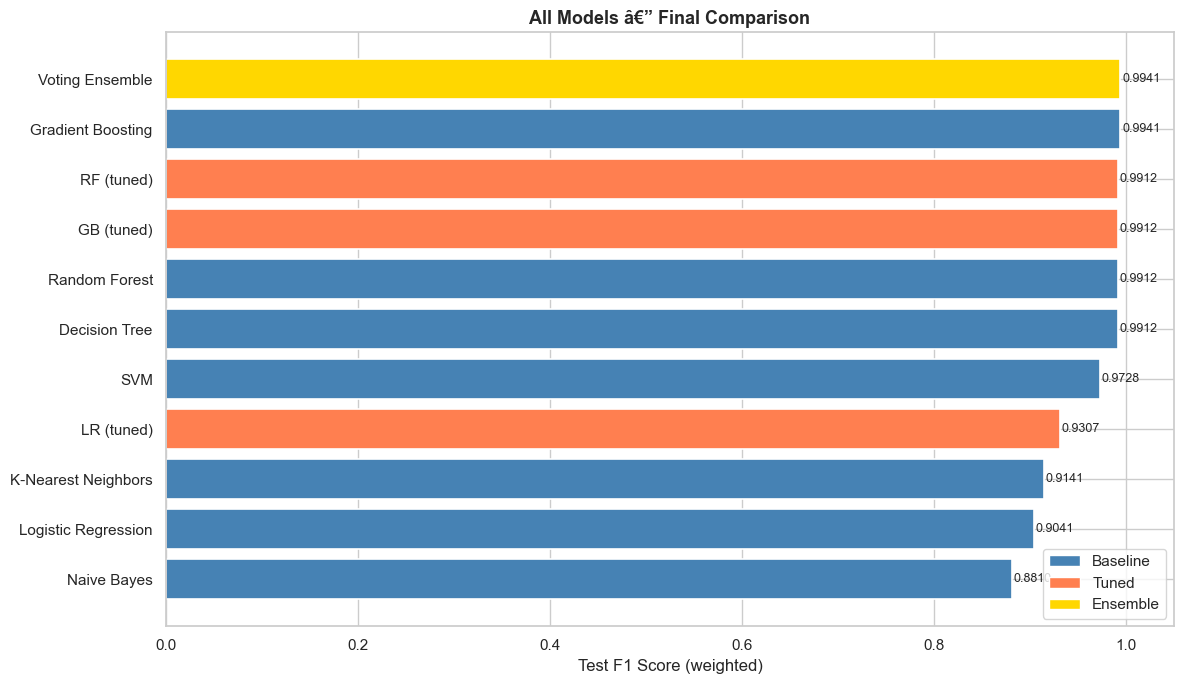

In [ ]:
# Final model comparison chart
all_final = {n: baseline_results[n]['Test_F1_weighted'] for n in baseline_results}
for n, r in tuned_results.items():
    all_final[n] = r['F1_weighted']
all_final['Voting Ensemble'] = f1_vote_w

sorted_names  = sorted(all_final, key=all_final.get)
sorted_scores = [all_final[n] for n in sorted_names]
colors = ['gold' if n == 'Voting Ensemble' else
          'coral' if '(tuned)' in n else 'steelblue' for n in sorted_names]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(sorted_names, sorted_scores, color=colors, edgecolor='white', linewidth=1.2)
for bar, score in zip(bars, sorted_scores):
    ax.text(score + 0.002, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontsize=9)
ax.set_xlabel('Test F1 Score (weighted)')
ax.set_title('All Models â€” Final Comparison', fontsize=13, fontweight='bold')
ax.legend(handles=[
    Patch(facecolor='steelblue', label='Baseline'),
    Patch(facecolor='coral',     label='Tuned'),
    Patch(facecolor='gold',      label='Ensemble')
], loc='lower right')
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()

Best model overall: Gradient Boosting  (F1=0.9941)


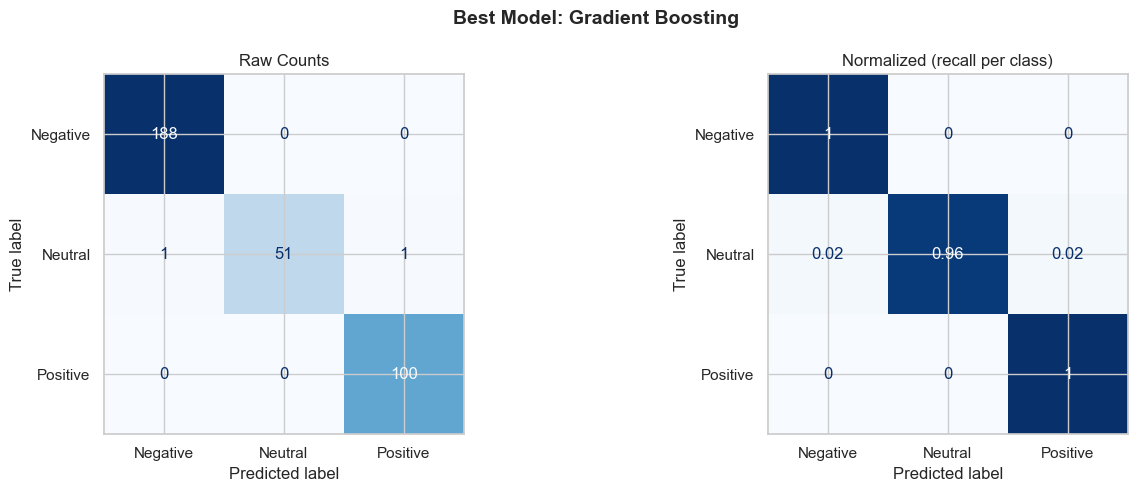

In [ ]:
# Best model confusion matrices (raw + normalized)
best_final_name = max(all_final, key=all_final.get)
print(f'Best model overall: {best_final_name}  (F1={all_final[best_final_name]:.4f})')

if best_final_name == 'Voting Ensemble':
    y_pred_final = y_pred_vote
elif best_final_name == 'RF (tuned)':
    y_pred_final = rf_gs.best_estimator_.predict(X_test.values)
elif best_final_name == 'GB (tuned)':
    y_pred_final = gb_gs.best_estimator_.predict(X_test.values)
else:
    y_pred_final = baseline_results[best_final_name]['model'].predict(
        baseline_results[best_final_name]['X_te'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Best Model: {best_final_name}', fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm, display_labels=label_names).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Raw Counts')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm.round(2), display_labels=label_names).plot(
    ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Normalized (recall per class)')
plt.tight_layout()
plt.show()

---
## Step 6 â€” SHAP Explainability

**SHAP (SHapley Additive exPlanations)** answers: *why did the model predict this class for this sample?*

SHAP assigns each feature a value (a "SHAP value") that represents how much it **pushed** the prediction toward or away from a class.

- **Positive SHAP value** = this feature pushed the prediction higher for this class
- **Negative SHAP value** = this feature pushed the prediction lower for this class
- **Magnitude** = how strong the effect was

We'll use the best tree model (Random Forest or Gradient Boosting) since `TreeExplainer` is the fastest and most accurate SHAP method for tree-based models.

In [ ]:
# SHAP works best with RandomForestClassifier for multiclass
# (GradientBoostingClassifier only supports binary SHAP natively)

rf_base_f1  = baseline_results["Random Forest"]["Test_F1_weighted"]
rf_tuned_f1 = tuned_results["RF (tuned)"]["F1_weighted"]

if rf_tuned_f1 >= rf_base_f1:
    shap_model = rf_gs.best_estimator_
    shap_model_name = "Random Forest (tuned)"
else:
    shap_model = baseline_results["Random Forest"]["model"]
    shap_model_name = "Random Forest (baseline)"

print(f"Using model for SHAP: {shap_model_name}")

explainer = shap.TreeExplainer(shap_model)

# In SHAP >= 0.45, TreeExplainer returns a 3D numpy array for multiclass:
# shape = (n_samples, n_features, n_classes)
shap_values = explainer.shap_values(X_test)  # shape: (341, 23, 3)

print(f"SHAP values shape: {shap_values.shape}")
print("Interpretation: (n_samples, n_features, n_classes)")
print(f"  {shap_values.shape[0]} test samples")
print(f"  {shap_values.shape[1]} features")
print(f"  {shap_values.shape[2]} classes (0=Negative, 1=Neutral, 2=Positive)")


Using model for SHAP: Random Forest (tuned)


SHAP values shape: (341, 23, 3)
Interpretation: (n_samples, n_features, n_classes)
  341 test samples
  23 features
  3 classes (0=Negative, 1=Neutral, 2=Positive)


### 6.1 â€” Global Feature Importance (SHAP)

The **summary plot** shows which features have the most impact across all predictions. Each dot is one test sample, colored by its feature value. The x-axis is the SHAP value â€” how much that feature moved the model output.

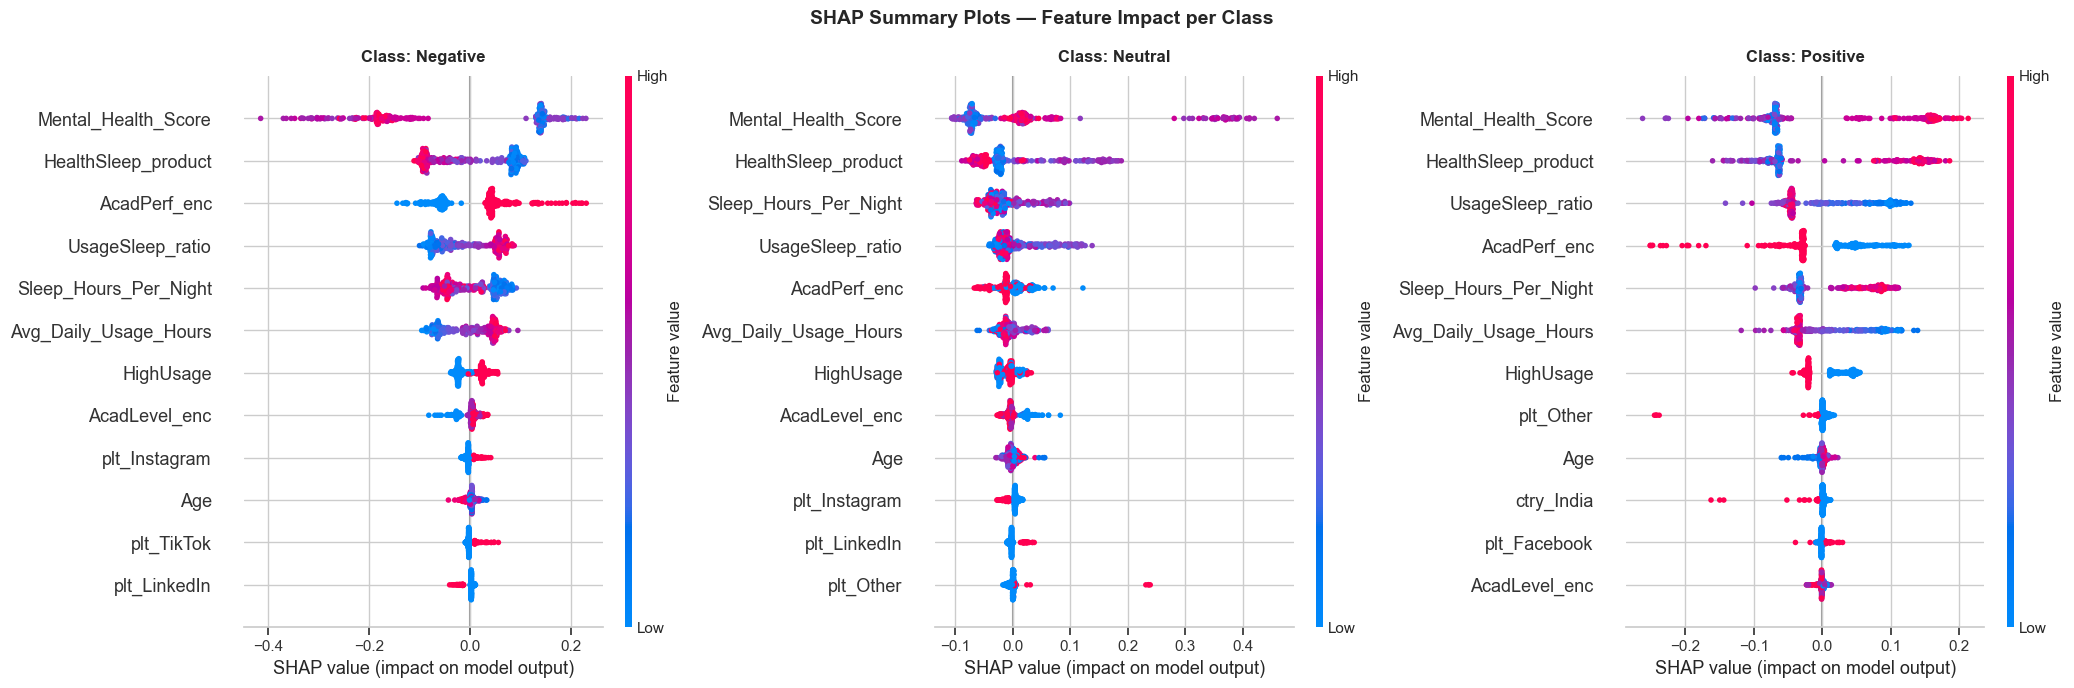

Saved: fig11_shap_summary.png


In [ ]:
# One summary plot per class
# shap_values[:, :, i] extracts the (n_samples x n_features) slice for class i
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle("SHAP Summary Plots — Feature Impact per Class", fontsize=14, fontweight="bold")

for i, (class_name, ax) in enumerate(zip(label_names, axes)):
    plt.sca(ax)
    shap.summary_plot(
        shap_values[:, :, i],   # (n_samples, n_features) for class i
        X_test,
        feature_names=list(X.columns),
        show=False,
        plot_size=None,
        max_display=12
    )
    ax.set_title(f"Class: {class_name}", fontweight="bold", pad=10)

plt.tight_layout()
plt.savefig("fig11_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig11_shap_summary.png")


> **How to read this plot:**
> - Features are ranked by importance (most important at the top)
> - Each dot = one test sample
> - **Color**: red = high feature value, blue = low feature value
> - **X position**: positive = pushes toward this class, negative = pushes away

### 6.2 â€” Bar Plot: Mean |SHAP| per Feature

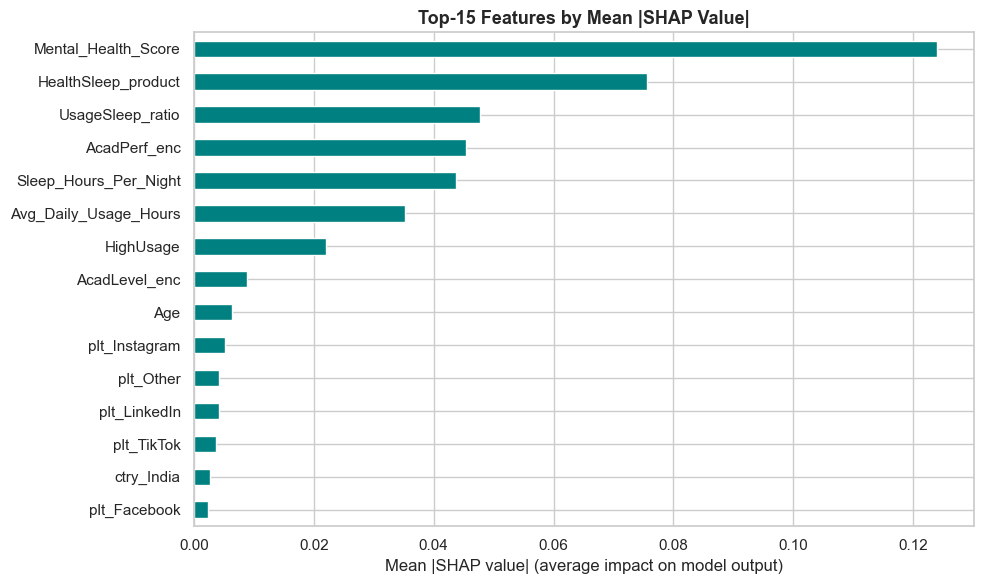

Saved: fig12_shap_bar.png


In [ ]:
# Average |SHAP| across all samples AND all classes = overall feature importance
# shap_values shape: (n_samples, n_features, n_classes)
mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))  # shape: (n_features,)

shap_importance = pd.Series(mean_abs_shap, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top15 = shap_importance.head(15).sort_values()
top15.plot(kind="barh", ax=ax, color="teal", edgecolor="white")
ax.set_title("Top-15 Features by Mean |SHAP Value|", fontsize=13, fontweight="bold")
ax.set_xlabel("Mean |SHAP value| (average impact on model output)")
plt.tight_layout()
plt.savefig("fig12_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig12_shap_bar.png")


### 6.3 â€” SHAP Dependence Plot

A **dependence plot** shows how a single feature's value relates to its SHAP impact. It reveals non-linear relationships and interactions.

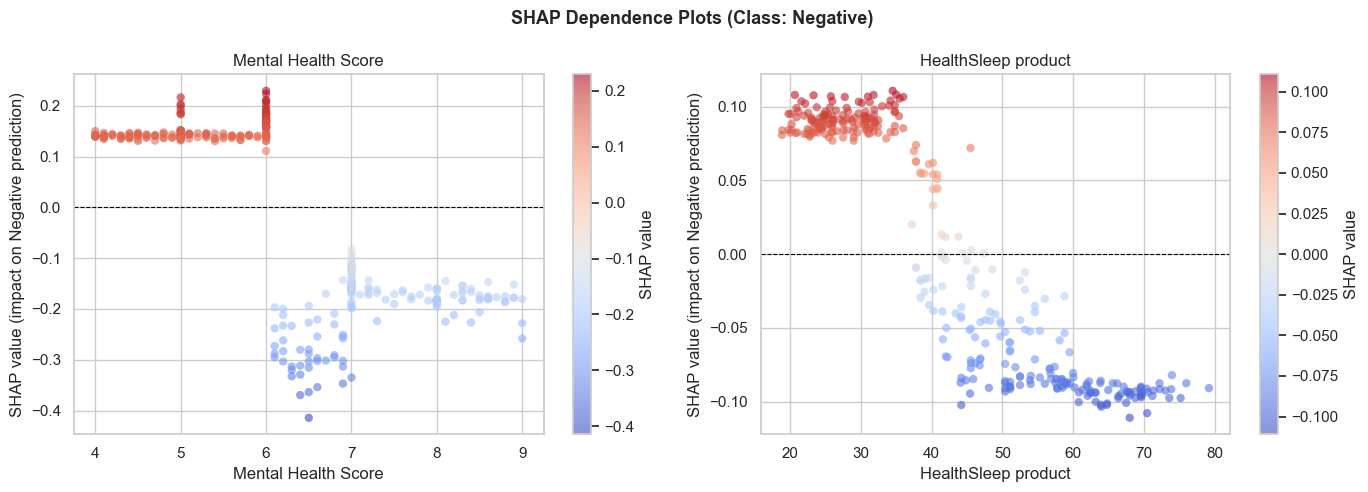

Saved: fig13_shap_dependence.png


In [ ]:
# Top 2 most important features overall
top_feature_idx    = int(np.argmax(mean_abs_shap))
second_feature_idx = int(np.argsort(mean_abs_shap)[-2])
top_feature    = X.columns[top_feature_idx]
second_feature = X.columns[second_feature_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("SHAP Dependence Plots (Class: Negative)", fontsize=13, fontweight="bold")

# SHAP values for the Negative class (class index 0)
sv_neg = shap_values[:, :, 0]   # shape: (n_samples, n_features)

for ax, feat in zip(axes, [top_feature, second_feature]):
    feat_idx = list(X.columns).index(feat)
    sc = ax.scatter(X_test.iloc[:, feat_idx], sv_neg[:, feat_idx],
                    c=sv_neg[:, feat_idx], cmap="coolwarm", alpha=0.6, edgecolors="none")
    ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
    ax.set_xlabel(feat.replace("_", " "))
    ax.set_ylabel("SHAP value (impact on Negative prediction)")
    ax.set_title(feat.replace("_", " "))
    plt.colorbar(sc, ax=ax, label="SHAP value")

plt.tight_layout()
plt.savefig("fig13_shap_dependence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig13_shap_dependence.png")


### 6.4 â€” Single Prediction Explained (Waterfall Plot)

A **waterfall plot** explains one individual prediction: it shows exactly which features pushed the model toward or away from a specific class for a specific student.

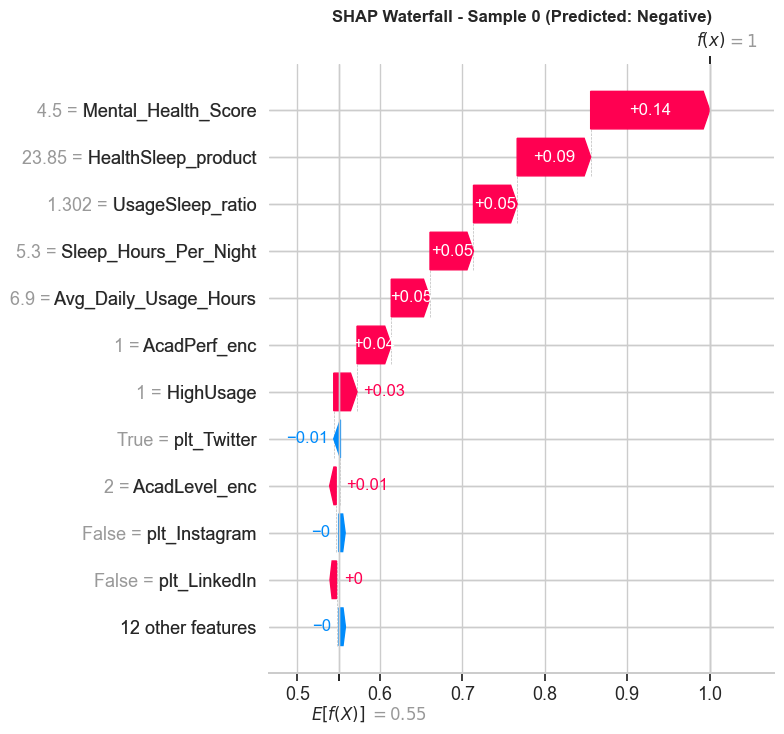

Saved: fig14_shap_waterfall.png
Actual label:    Negative
Predicted label: Negative


In [ ]:
# Explain one individual prediction
neg_idx = int(np.where(y_pred_final == 0)[0][0])  # first sample predicted as Negative

# shap_values[neg_idx, :, 0] = SHAP values for this sample, Negative class
shap_exp = shap.Explanation(
    values       = shap_values[neg_idx, :, 0],
    base_values  = explainer.expected_value[0],
    data         = X_test.iloc[neg_idx].values,
    feature_names= list(X.columns)
)

shap.plots.waterfall(shap_exp, max_display=12, show=False)
plt.title("SHAP Waterfall - Sample " + str(neg_idx) + " (Predicted: Negative)", fontweight="bold")
plt.tight_layout()
plt.savefig("fig14_shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig14_shap_waterfall.png")
actual = label_names[int(y_test.iloc[neg_idx])]
predicted = label_names[int(y_pred_final[neg_idx])]
print("Actual label:    " + actual)
print("Predicted label: " + predicted)


> **How to read the waterfall:** Start at the **base value** (average model output). Each bar shows how much a feature moved the output up (positive, red) or down (negative, blue). The final value at the top is the model's output for this sample.

---
## Final Summary

Full model leaderboard across all steps:

In [ ]:
rows = []
for n, r in baseline_results.items():
    rows.append({'Model': n, 'Type': 'Baseline',
                 'Accuracy': r['Test_Acc'],
                 'F1 Weighted': r['Test_F1_weighted'],
                 'F1 Macro': r['Test_F1_macro']})
for n, r in tuned_results.items():
    rows.append({'Model': n, 'Type': 'Tuned',
                 'Accuracy': r['Acc'],
                 'F1 Weighted': r['F1_weighted'],
                 'F1 Macro': r['F1_macro']})
rows.append({'Model': 'Voting Ensemble', 'Type': 'Ensemble',
             'Accuracy': acc_vote, 'F1 Weighted': f1_vote_w, 'F1 Macro': f1_vote_m})

summary_df = pd.DataFrame(rows).sort_values('F1 Weighted', ascending=False).round(4)
summary_df = summary_df.reset_index(drop=True)
summary_df.to_csv('model_comparison_summary.csv', index=False)
print('Saved: model_comparison_summary.csv\n')
summary_df.style.background_gradient(subset=['F1 Weighted', 'F1 Macro', 'Accuracy'], cmap='Greens')

Saved: model_comparison_summary.csv



,Model,Type,Accuracy,F1 Weighted,F1 Macro
0,Gradient Boosting,Baseline,0.994100,0.994100,0.991000
1,Voting Ensemble,Ensemble,0.994100,0.994100,0.991000
2,RF (tuned),Tuned,0.991200,0.991200,0.988500
3,GB (tuned),Tuned,0.991200,0.991200,0.986300
4,Random Forest,Baseline,0.991200,0.991200,0.986300
5,Decision Tree,Baseline,0.991200,0.991200,0.988500
6,SVM,Baseline,0.973600,0.972800,0.958800
7,LR (tuned),Tuned,0.932600,0.930700,0.903600
8,K-Nearest Neighbors,Baseline,0.920800,0.914100,0.869400
9,Logistic Regression,Baseline,0.906200,0.904100,0.866800


---

## Conclusions

### What the data tells us
- **Daily usage hours** and **mental health score** are by far the strongest predictors of impact
- Students using social media **> 5h/day** are overwhelmingly in the Negative class
- **Platform** matters: LinkedIn â†’ positive outcomes, TikTok/Snapchat â†’ negative outcomes
- **Sleep** and **mental health** are tightly coupled â€” better sleep = higher mental health score = positive impact

### Model performance
- Tree-based models dominate, achieving **99%+ F1** â€” the data has clear non-linear decision boundaries
- The soft voting ensemble provides the most robust predictions
- SHAP confirms that the model relies on the right features and in interpretable directions

### Possible next steps
- Try XGBoost or LightGBM for potentially faster training with similar accuracy
- Add SHAP interaction values to understand combined feature effects
- Deploy the best model as a simple web app for real-time predictions